# 1. Exploratory Data Analysis для датасета [Adult Census Income](https://archive.ics.uci.edu/dataset/2/adult)

In [2]:
# нужные импорты
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
sns.set(style='darkgrid')

В качестве датасета было решено взять данные о доходах (Adult Income) для задачи бинарной классификации (годовой доход индивида больше 50000$)

In [3]:
!wget -q -P data/ https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
!wget -q -P data/ https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test

In [4]:
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


train = pd.read_csv('data/adult.data', names=columns, skipinitialspace=True, na_values=['?'])
test = pd.read_csv('data/adult.test', names=columns, skipinitialspace=True, na_values=['?'], skiprows=1)
test['income'] = test['income'].str.rstrip('.') # тк в тесте точка на конце

## Общая информация о датасете

In [5]:
# размеры датасета
print(f'Train: {train.shape[0]}, Test: {test.shape[0]}')
# число признаков
print(f'Число признаков: {train.shape[1]}')
# признаки
print(*list(train.columns))

Train: 32561, Test: 16281
Число признаков: 15
age workclass fnlwgt education education-num marital-status occupation relationship race sex capital-gain capital-loss hours-per-week native-country income


In [6]:
# типы данных
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Из самого поверхностного взгляда на данные можем заметить, что у нас 16 признаков, среди которых есть категориальные

## Проверка пропусков

Из описания данных в архиве мы знаем что пропуски в них есть и обозначены `?`. При загрузке мы их заменили на Nan и теперь обработаем их

In [7]:
# проверяем train
train.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [8]:
# посмотрим на процент пропусков
train.isna().sum()/train.shape[0]

age               0.000000
workclass         0.056386
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.056601
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.017905
income            0.000000
dtype: float64

Видим что пропуски составляют около 5% или даже меньше в тех категориях, где есть пропуски. Тк пропуски у нас в категориальных признаках, то заменим пропуски категорией `Unknown`

In [9]:
train.fillna('Unknown', inplace=True)

In [10]:
# аналогично для test
test.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [11]:
test.isna().sum()/test.shape[0]

age               0.000000
workclass         0.059149
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.059333
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.016829
income            0.000000
dtype: float64

In [12]:
test.fillna('Unknown', inplace=True)

## Target analysis

<Axes: xlabel='income', ylabel='Count'>

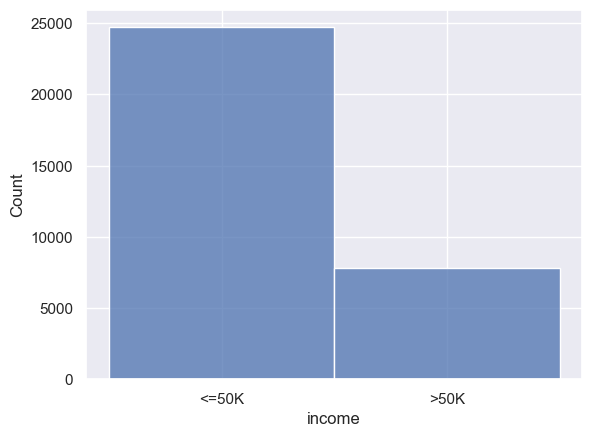

In [13]:
# посмотрим на распределение целевой переменной
sns.histplot(train['income'])

In [14]:
# доля классов
train['income'].value_counts()/train.shape[0]

income
<=50K    0.75919
>50K     0.24081
Name: count, dtype: float64

Заметим что в обучающей выборке имеет место умеренный дисбаланс классов (76% на 24% соответственно), но он не критичный. Самая обычная константная модель, которая выдает более многочисленный класс, будет давать accuracy около 0.76. Следовательно accuracy не является надежной метрикой качества модели и лучше использовать другие метрики качества классификации, например AUC-ROC

## Типы признаков

In [15]:
# посмотрим какие признаки у нас категориальные, а какие числовые
cat_features = train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Исключаем целевую переменную
if 'income' in cat_features:
    cat_features.remove('income')

In [16]:
print(f'Категориальные: {cat_features}\nЧисловые: {num_features}')

Категориальные: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Числовые: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


## Анализ категориальных признаков

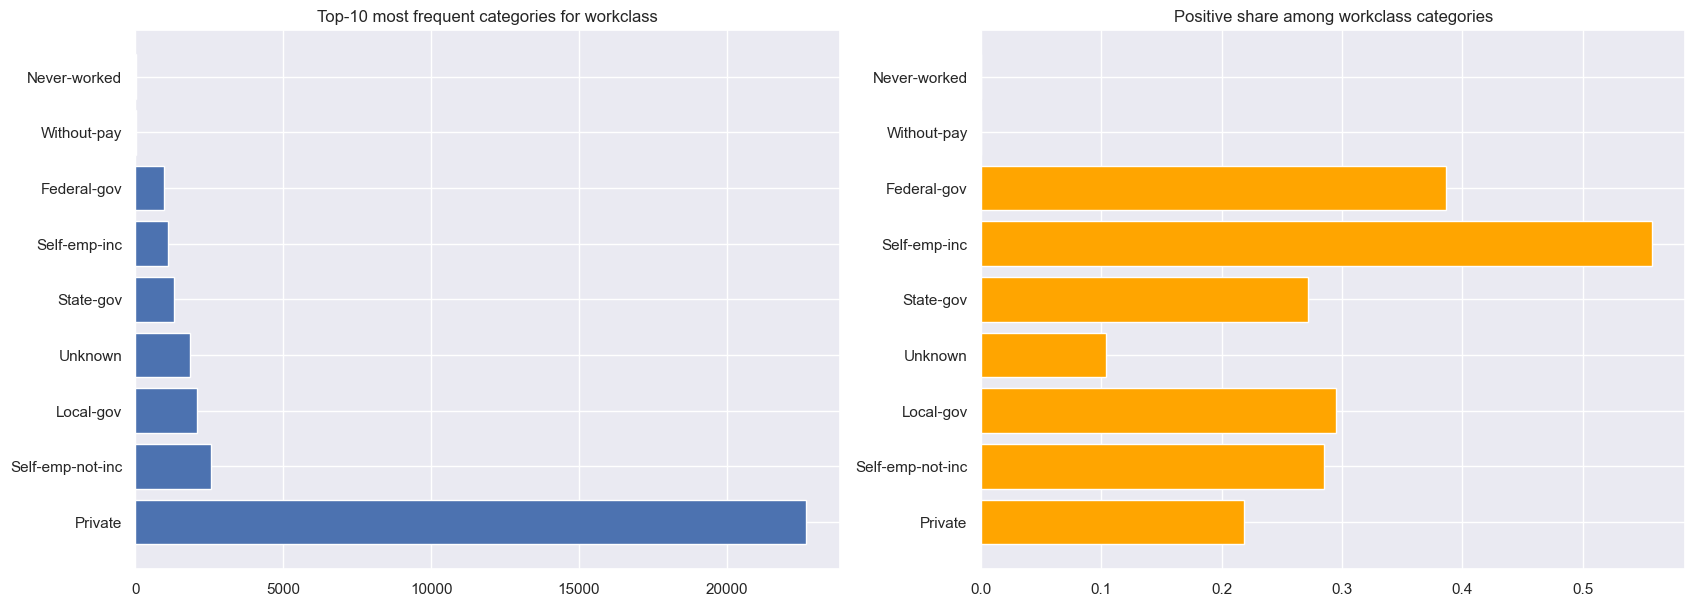

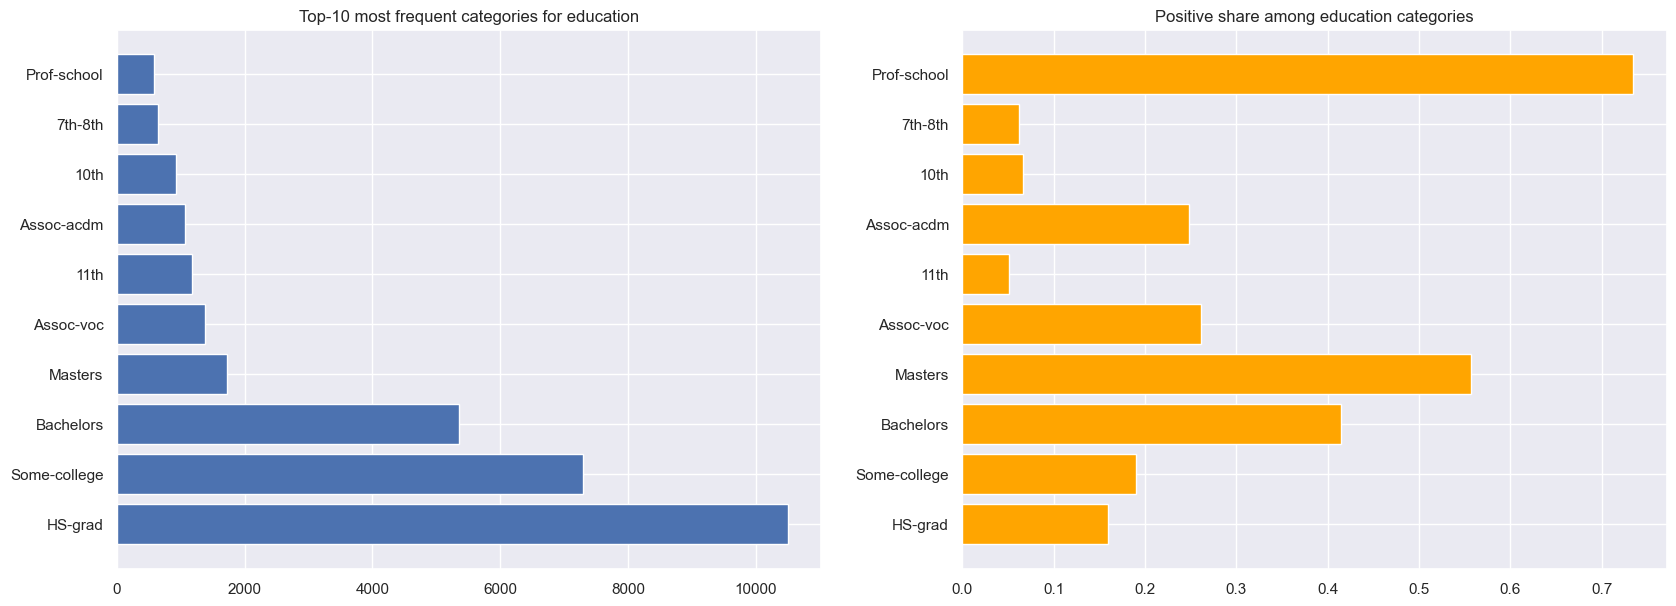

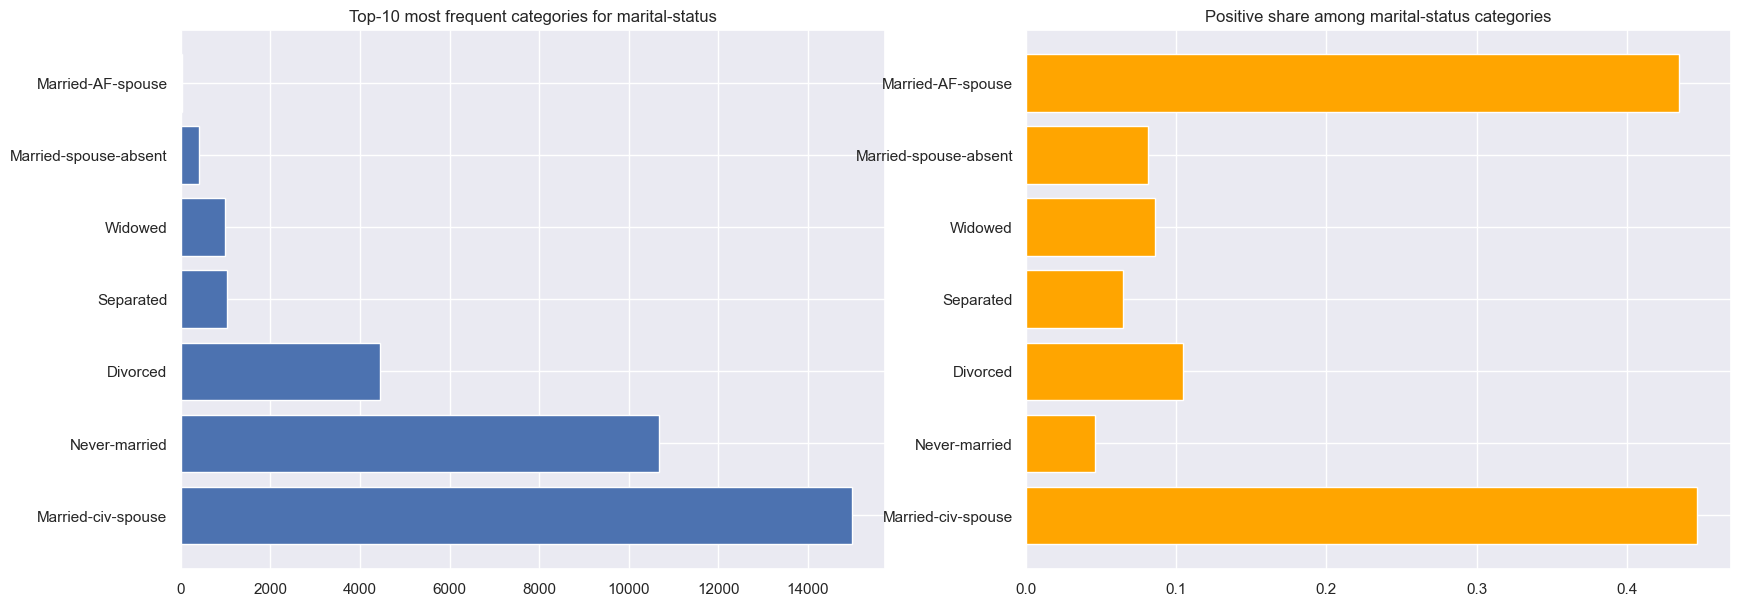

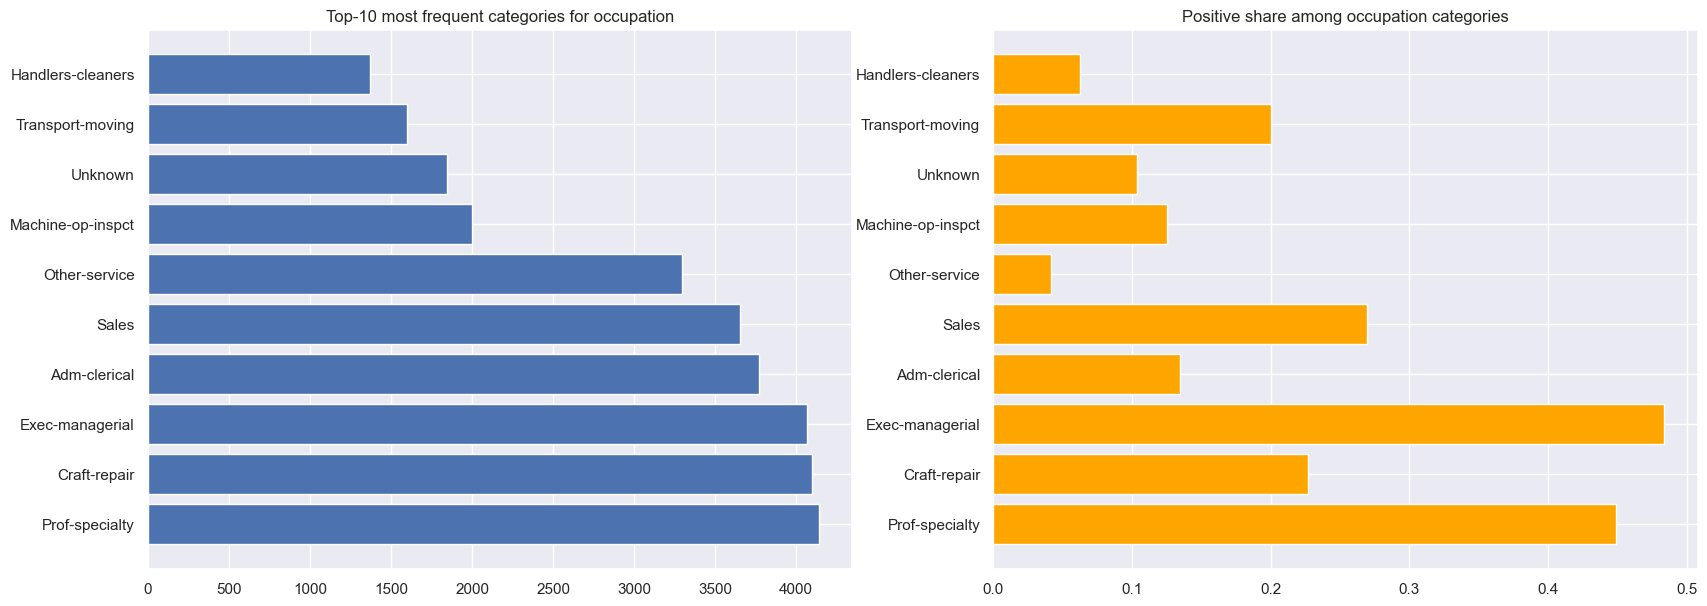

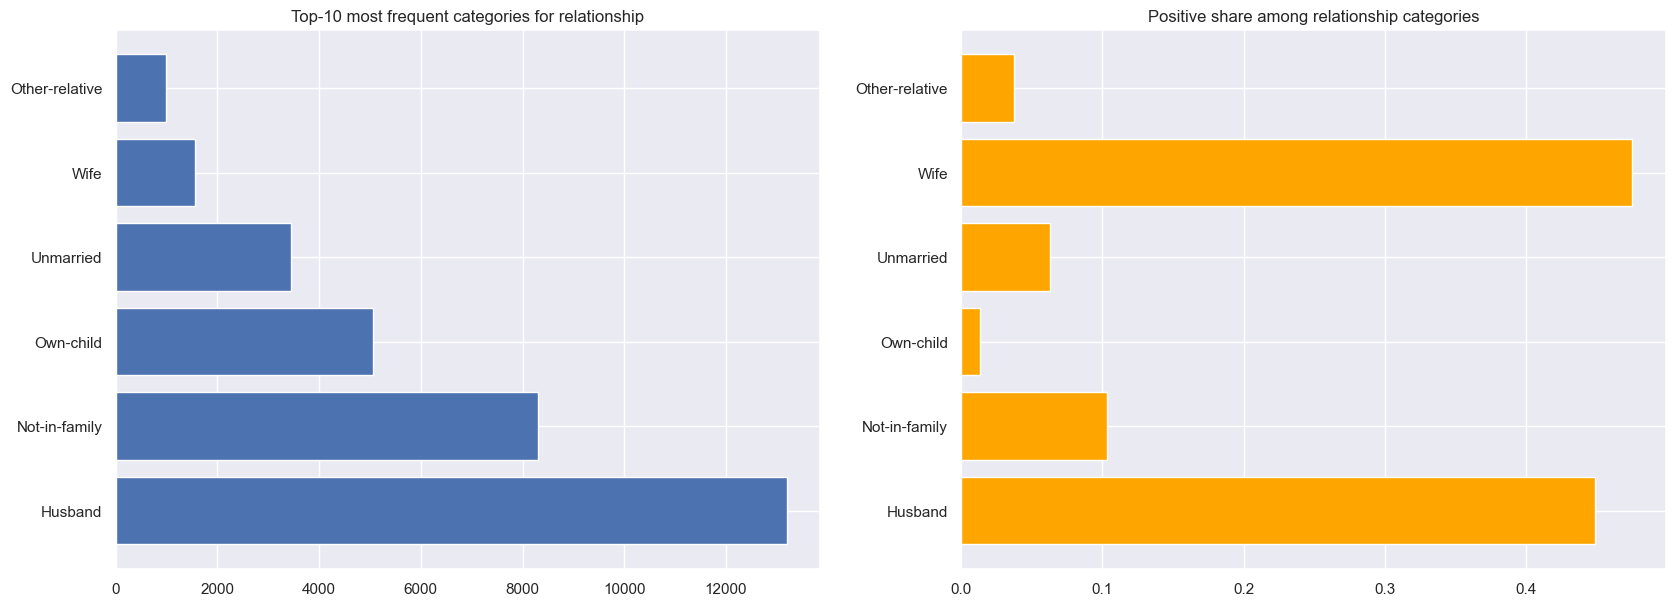

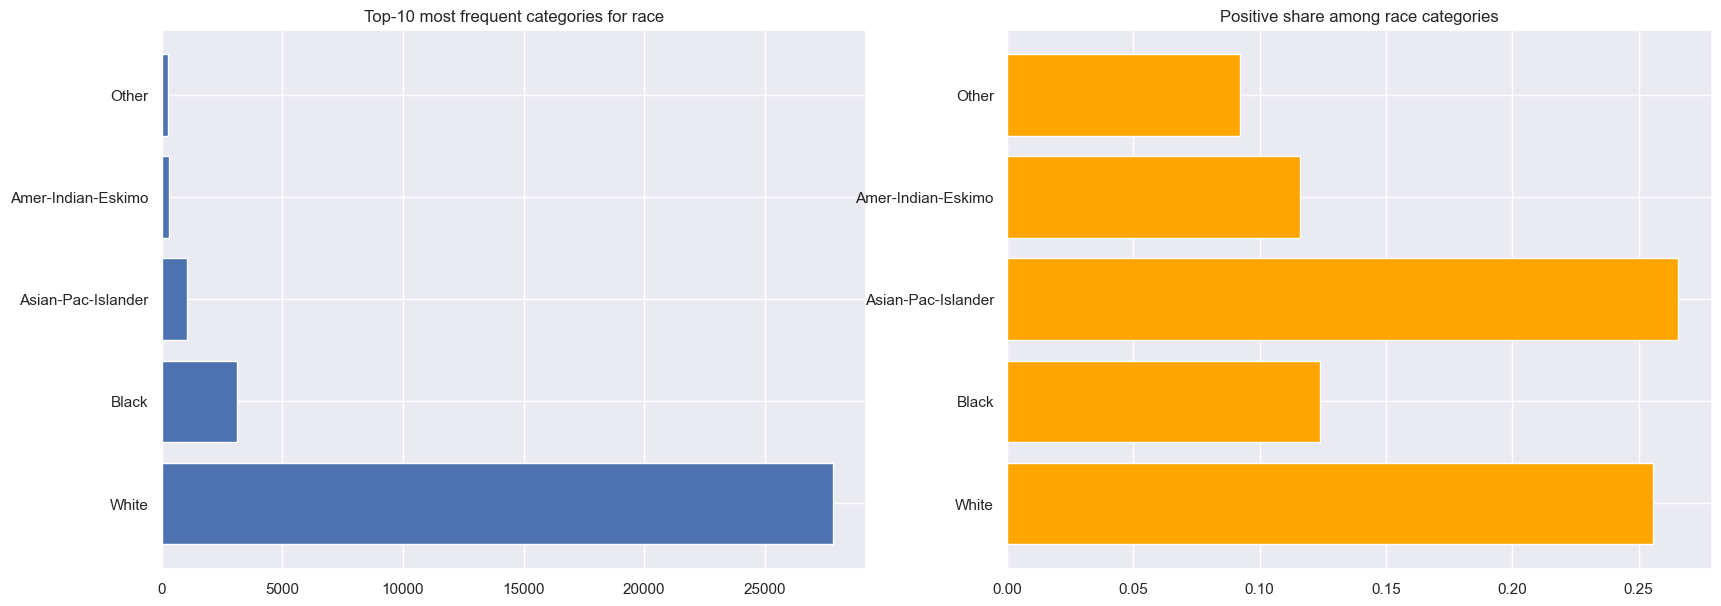

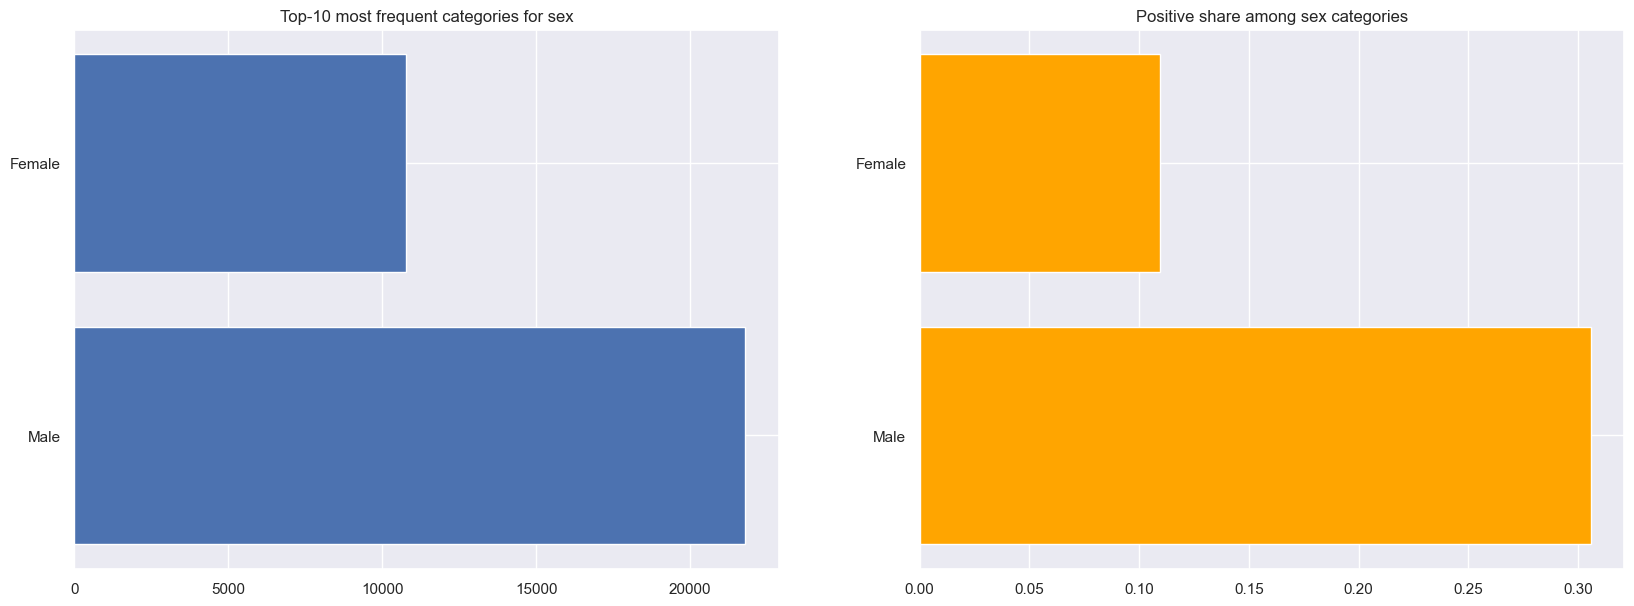

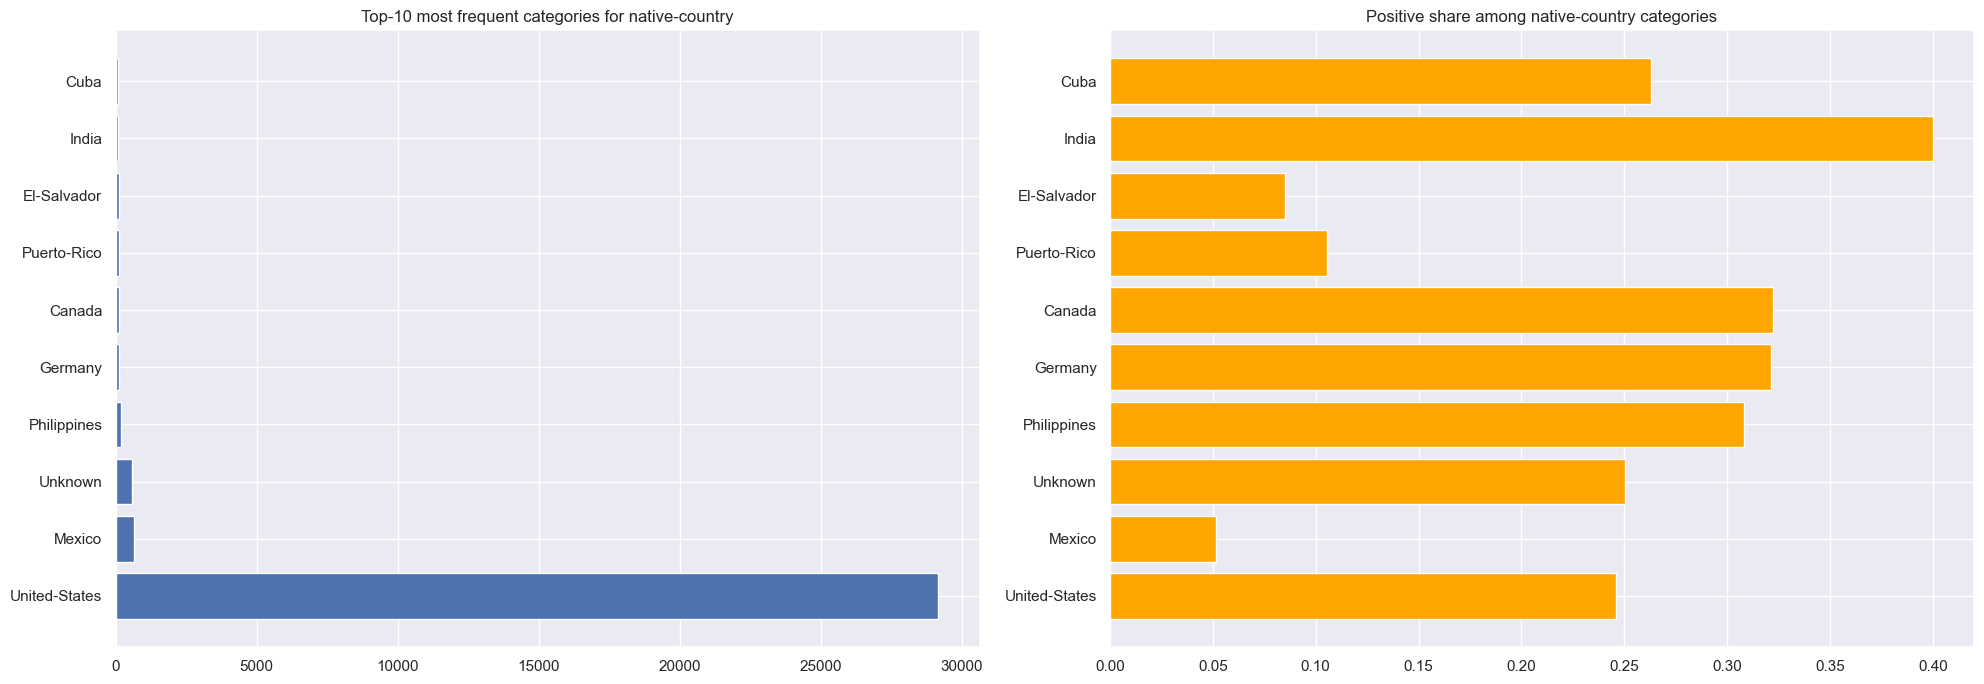

In [17]:
for i in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    # смотрим количество уникальных значений
    top10_cat = train[i].value_counts().head(10) # смотрим на 10 самых популярных категорий для удобства визуализации
    axes[0].barh(range(len(top10_cat)), top10_cat.values)
    axes[0].set_yticks(range(len(top10_cat)))
    axes[0].set_yticklabels(top10_cat.index)
    axes[0].set_title(f'Top-10 most frequent categories for {i}')
    
    # target rate по наиболее частым категориям
    positive_share = train[train[i].isin(top10_cat.index)].groupby(i)['income'].apply(lambda x: (x == '>50K').mean()).loc[top10_cat.index]
    axes[1].barh(range(len(positive_share)), positive_share.values, color='orange')
    axes[1].set_yticks(range(len(positive_share)))
    axes[1].set_yticklabels(positive_share.index)
    axes[1].set_title(f'Positive share among {i} categories')
plt.tight_layout()

исходя из графиков сделаем следующие выводы:
- В признаке `workclass` категории self-emp-inc и federal-gov встречаются относительно редко, однако доля положительного класса в них превышает 40%, что может указывать на их высокую предсказательную силу.
- В признаке `education` наиболее распространенной категорией является HS-grad с долей положительного класса около 15%, тогда как менее распространенные категории, такие как Prof-school, демонстрируют значительно более высокую долю положительного класса (более 70%). Это указывает на сильную зависимость дохода от уровня образования.
- В признаке `marital-status` наиболее распространены категории married-civ-spouse и never-married. При этом наибольшая доля положительного класса наблюдается среди married-civ-spouse, а также среди married-AF-spouse, несмотря на малое количество наблюдений в последней категории.
- В признаке `occupation` наибольшая доля положительного класса наблюдается в категориях prof-specialty и exec-managerial (около 50%), что может свидетельствовать о высокой оплате в данных профессиональных группах.
- В признаке `relationship` наиболее распространены категории husband и not-in-family, однако доля положительного класса выше среди категорий, связанных с браком (husband, wife), что согласуется с наблюдениями по признаку marital-status.
- В признаке `race` преобладает категория white, при этом более высокая доля положительного класса наблюдается среди white и asian-pac-islander, что может указывать на различия в доходах между группами.
- В датасете мужчин примерно в два раза больше, чем женщин, и доля положительного класса среди мужчин также значительно выше.
- В признаке `native-country` доминирует категория United-States, что ожидаемо. При этом различия в доле положительного класса между странами выражены слабее, чем для других признаков.

Категориальные признаки демострируют очень сильную вариативность доли положительного класса по категориям, что может говорить о хорошем прогнозном потенциале. Некоторые признаки, такие как education, occupation, marital-status иллюстрируют понятную и интерпретируемую связь с доходом. Кроме того, взаимосвязь между признаками говорит о наличии сложных, нелинейных зависимостей, соответственно разумно использование моделей на основе решаюших деревьев, например GBM

## Анализ числовых признаков

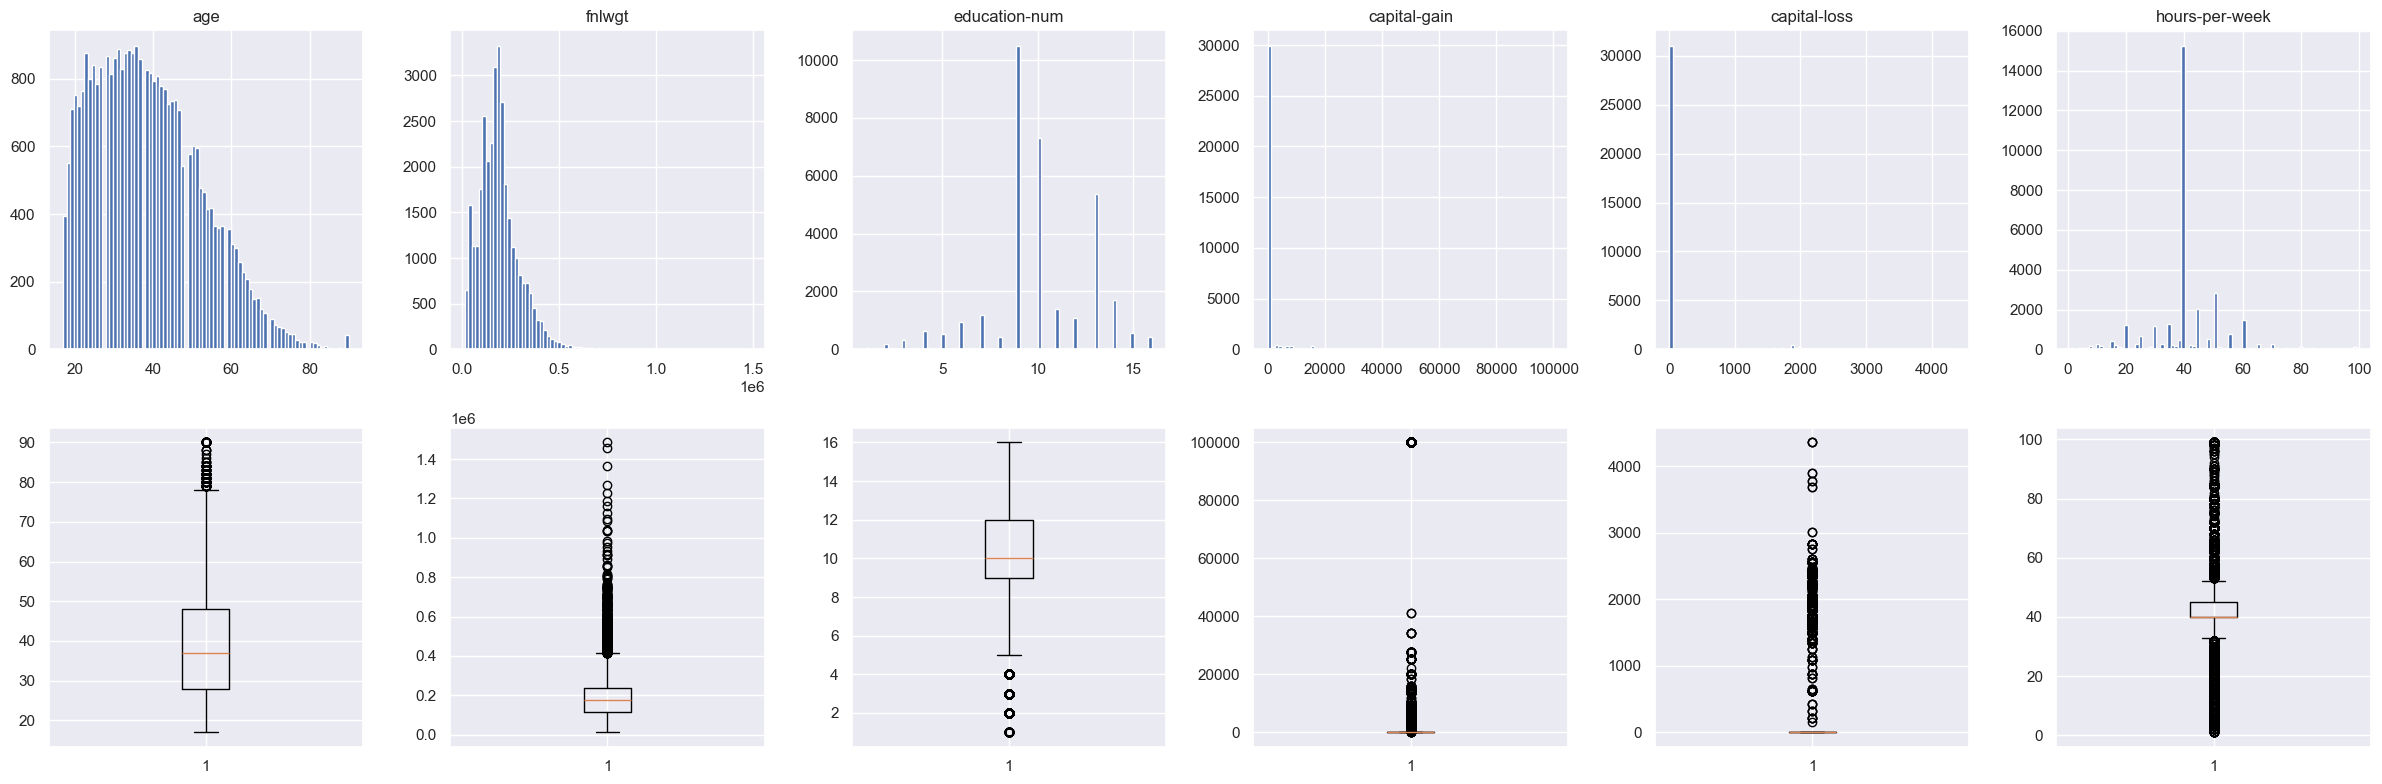

In [18]:
# Пройдемся по всем числовым признакам, посмотрим на распределение и выбросы
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for i in range(len(num_features)):
    axes[0][i].hist(train[num_features[i]], bins=80)
    axes[1][i].boxplot(train[num_features[i]])
    axes[0][i].set_title(num_features[i])
plt.tight_layout()

#### Из визуализаций можем сделать следующие выводы:
- признаки `capital-gain` и `capital-loss` очень сильно скошены вправо из-за большого количества около 0-вых значений и редких экстремальных значений. Это сигнализирует о наличии редких, но потенциально информативных наблюдений, которые могут создавать нелинейные границы принятия решений, что делает модели на основе деревьев особо полезными при решении данной задачи.
- признак `hours-per-week` имеет вырожденное распределение с модой 40 часов, что соответствует стандартной прололжительности рабочей недели
- признак `age` илюстрирует нормальный жизненный профиль: пик в районе взрослых работающих людей, дальше спад. Тут вероятна нелинейная связь с таргетом
- `education-num` - дискретный признак с несколькими выраженными уровнями. Это намекает, что связь с доходом может быть ступенчатой, а не линейной

В числовых признаках прослеживаются нелинейные зависимости, что делает градиентный бустинг подходящим вариантов для решения задачи.

## Корреляции

In [19]:
corr_matrix = train.corr(numeric_only=True)
corr_matrix

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


<Axes: >

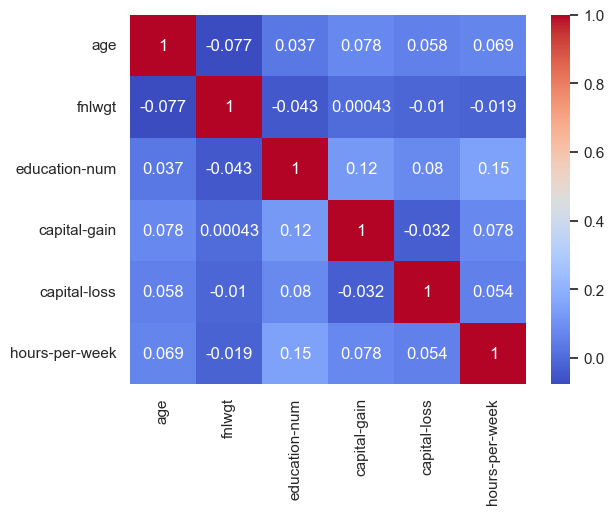

In [20]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

## Влияние признаков на target

Посмотрим на распределение некоторых числовых признаков в зависимости от целевой переменной

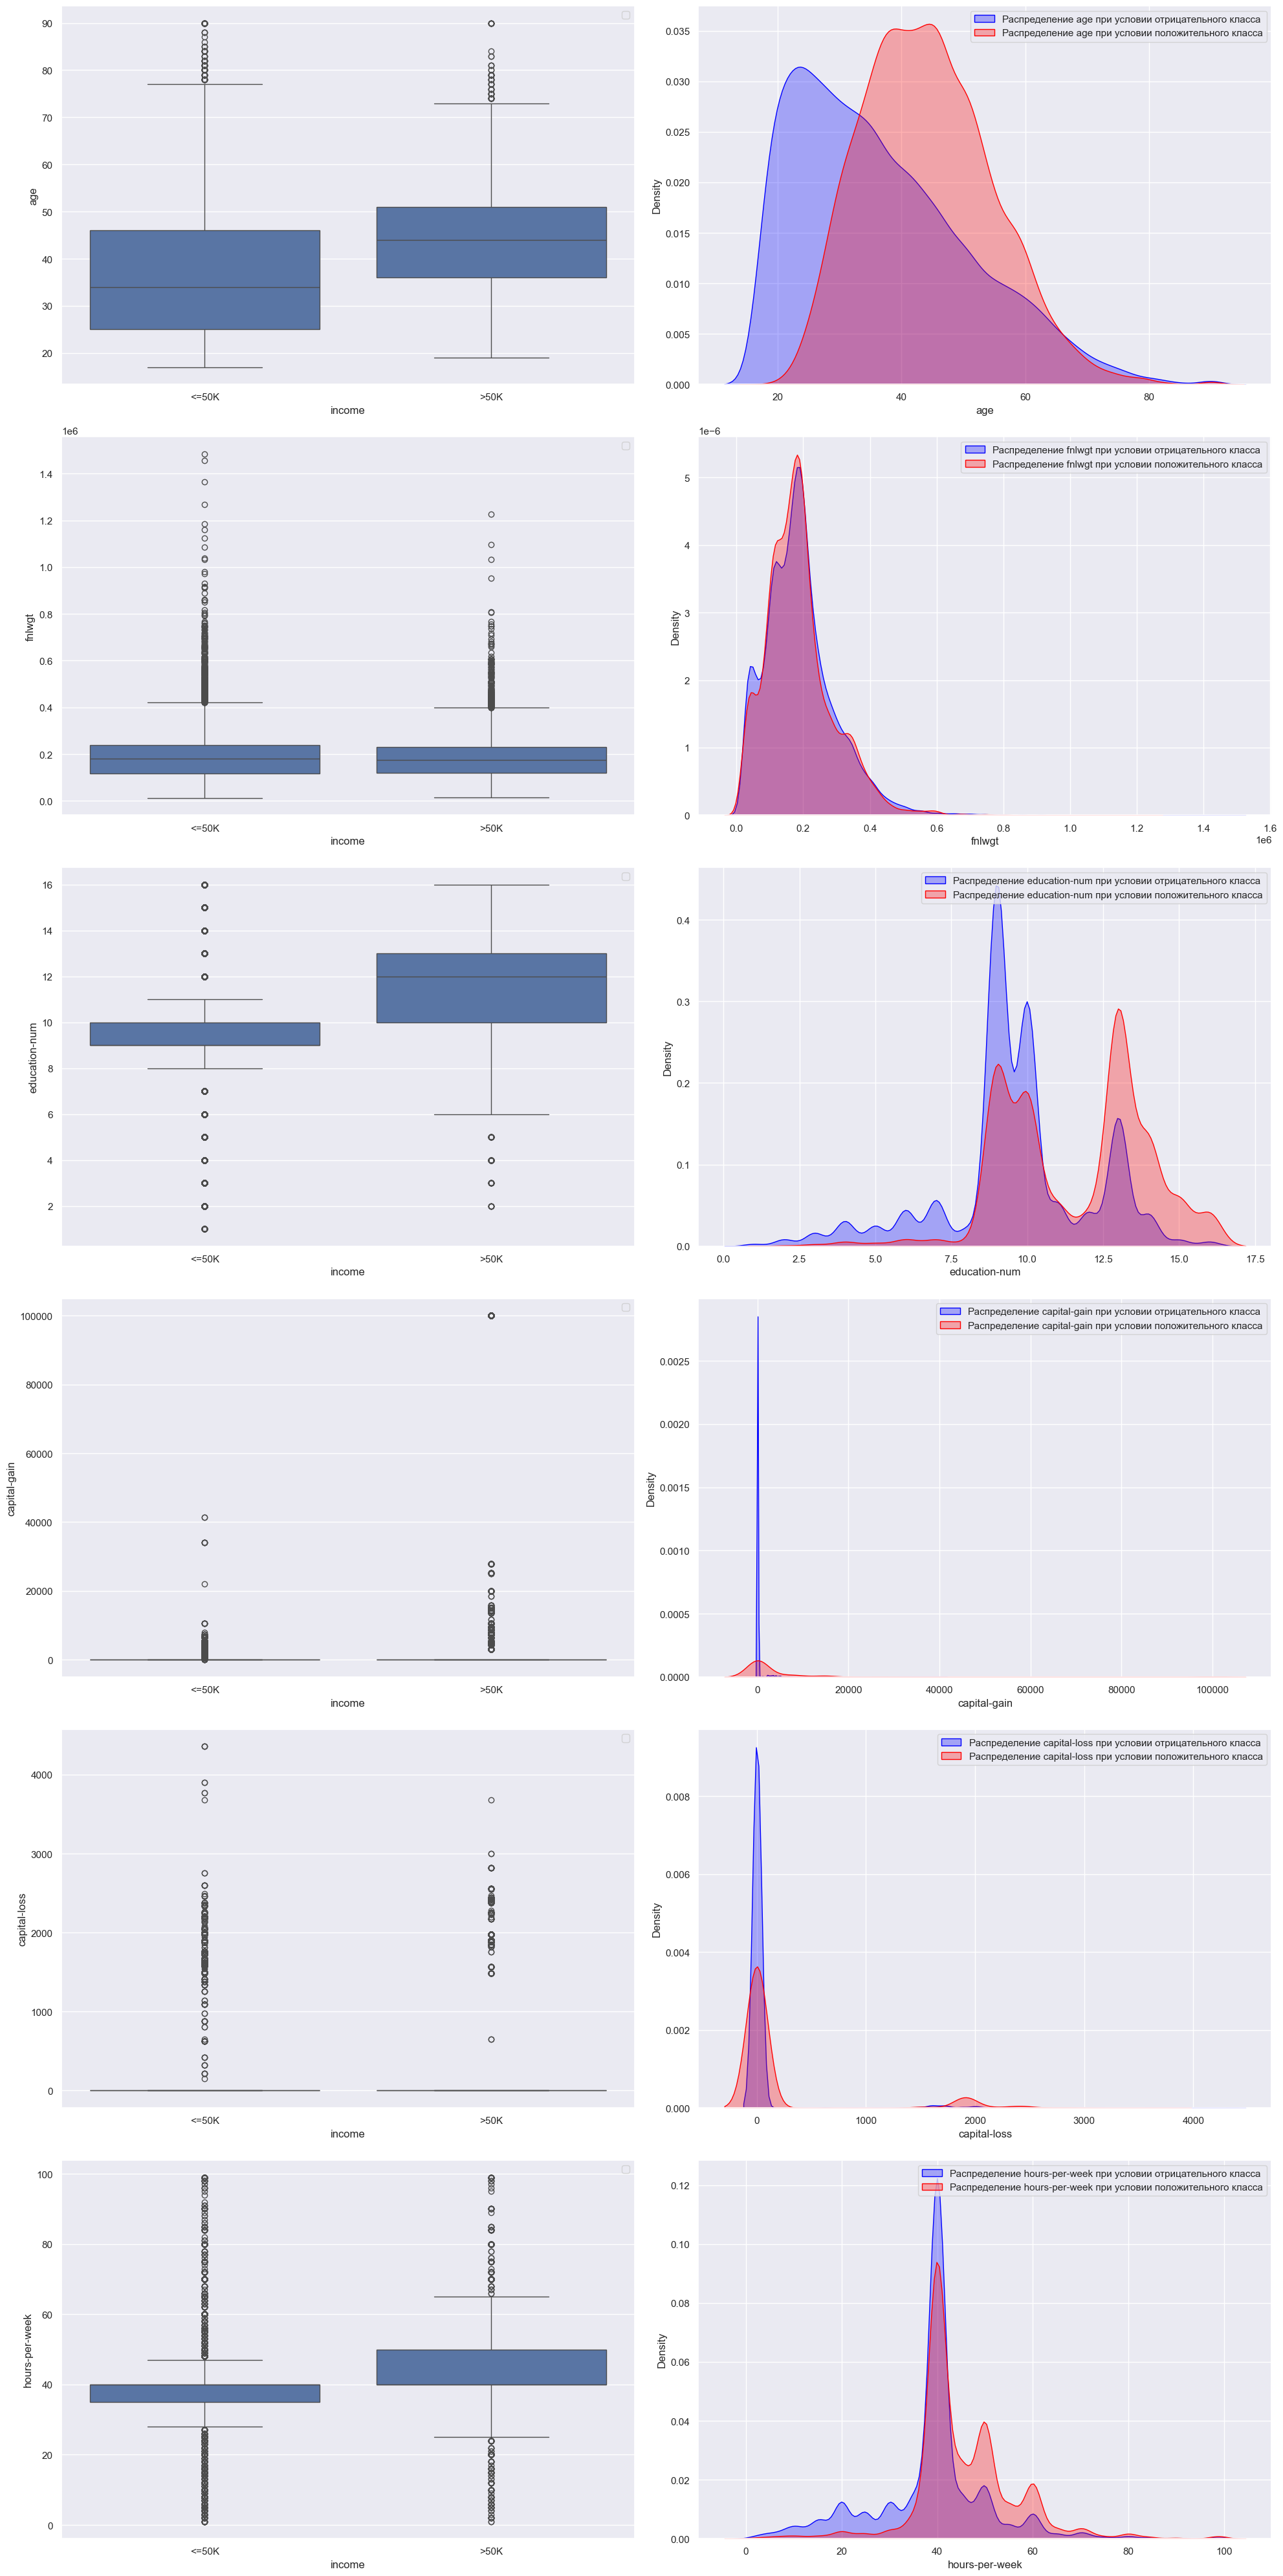

In [21]:
fig, axes = plt.subplots(6, 2, figsize=(20, 40))
for i, feature in enumerate(num_features):
    sns.boxplot(data=train, x='income', y=feature, ax=axes[i][0])
    sns.kdeplot(data=train[train['income']=='<=50K'][feature], label=f'Распределение {feature} при условии отрицательного класса',
                ax=axes[i][1], color='blue', fill=True, alpha=0.3)
    sns.kdeplot(data=train[train['income']=='>50K'][feature], label=f'Распределение {feature} при условии положительного класса',
                ax=axes[i][1], color='red', fill=True, alpha=0.3)
    axes[i][0].legend()
    axes[i][1].legend()
plt.tight_layout()
plt.show()

Из анализа распределений числовых признаков в зависимости от таргета можно сделать следующие наблюдения:
- Для большинства признаков (например, age, hours-per-week) распределения для положительного класса смещены вправо, что указывает на более высокие значения этих признаков у людей с доходом выше 50K. При этом распределения классов в целом значительно перекрываются, что свидетельствует об отсутствии линейной разделимости и указывает на нетривиальность задачи классификации и необходимость применения сложной модели, например модели на основе решеющего дерева, которая сможет найти нелинейные зависимости.
- Для признака capital-gain наблюдается наиболее выраженное различие между классами: высокие значения практически исключительно соответствуют положительному классу, несмотря на большое количество нулевых значений.
- Для большинства признаков (кроме fnlwgt) медиана выше для положительного класса
- Признак fnlwgt не демонстрирует значимых различий между классами, что может указывать на его низкую предсказательную ценность.